In [ ]:
# Setup — imports, plotting config, device
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import os

os.makedirs("outputs", exist_ok=True)

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['figure.dpi'] = 100

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


Training images: 50000
Testing images : 10000
Image shape    : (3, 32, 32)
Number of classes: 10


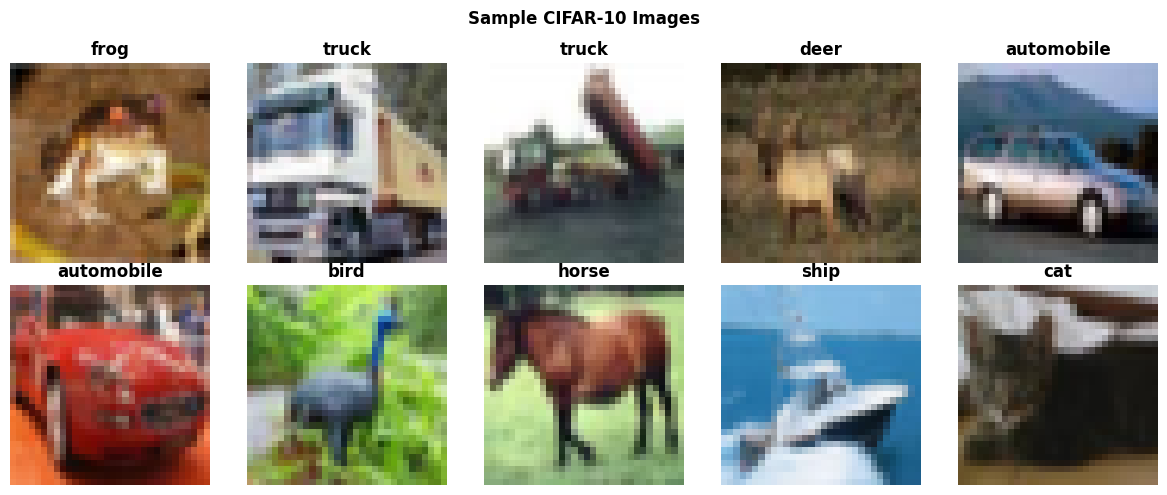

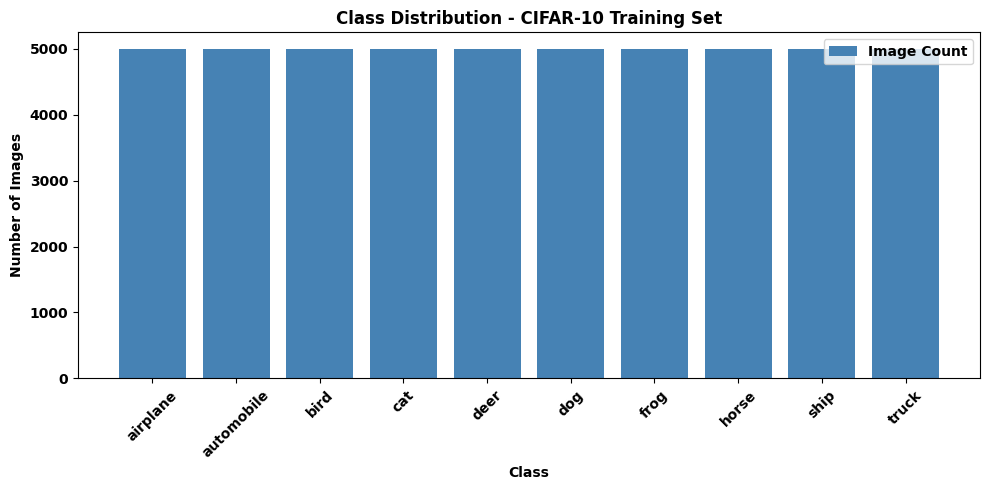

In [ ]:
# Task 1
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

classes = train_dataset.classes

print("Training images:", len(train_dataset))
print("Testing images :", len(test_dataset))
print("Image shape    :", tuple(train_dataset[0][0].shape))
print("Number of classes:", len(classes))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(classes[label], fontweight='bold')
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images", fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/1_sample_images.png", dpi=200)
plt.show()


labels = [label for _, label in train_dataset]
counts = np.bincount(labels)

plt.figure(figsize=(10, 5))
plt.bar(classes, counts, color='steelblue', label='Image Count')
plt.xlabel("Class", fontweight='bold')
plt.ylabel("Number of Images", fontweight='bold')
plt.title("Class Distribution - CIFAR-10 Training Set", fontweight='bold')
plt.xticks(rotation=45)
plt.legend(prop={'weight': 'bold'})
plt.tight_layout()
plt.savefig("outputs/2_class_distribution.png", dpi=200)
plt.show()



In [ ]:
# Task 2
sample_img, _ = train_dataset[0]
sample_img = sample_img.unsqueeze(0)  # (1, 3, 32, 32)

kernel_sizes = [3, 5, 7]
print(f"{'Kernel':<10}{'Input Size':<15}{'Output Feature Map Size'}")
for k in kernel_sizes:
    conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=k, stride=1, padding=0)
    out = conv(sample_img)
    print(f"{k}x{k:<8}{sample_img.shape[-1]}x{sample_img.shape[-1]:<13}{out.shape[-1]}x{out.shape[-1]}")
# Formula check: N - F + 1  (stride=1, padding=0)


Kernel    Input Size     Output Feature Map Size
3x3       32x32           30x30
5x5       32x32           28x28
7x7       32x32           26x26


In [ ]:
# Task 3
configs = [
    {"stride": 1, "padding": 0, "name": "Stride=1, Padding=Valid(0)"},
    {"stride": 2, "padding": 0, "name": "Stride=2, Padding=Valid(0)"},
    {"stride": 1, "padding": 1, "name": "Stride=1, Padding=Same(1)"},
    {"stride": 2, "padding": 1, "name": "Stride=2, Padding=Same(1)"},
]

print(f"{'Configuration':<32}{'Output Size'}")
for cfg in configs:
    conv = nn.Conv2d(3, 8, kernel_size=3, stride=cfg["stride"], padding=cfg["padding"])
    out = conv(sample_img)
    print(f"{cfg['name']:<32}{out.shape[-1]}x{out.shape[-1]}")

Configuration                   Output Size
Stride=1, Padding=Valid(0)      30x30
Stride=2, Padding=Valid(0)      15x15
Stride=1, Padding=Same(1)       32x32
Stride=2, Padding=Same(1)       16x16


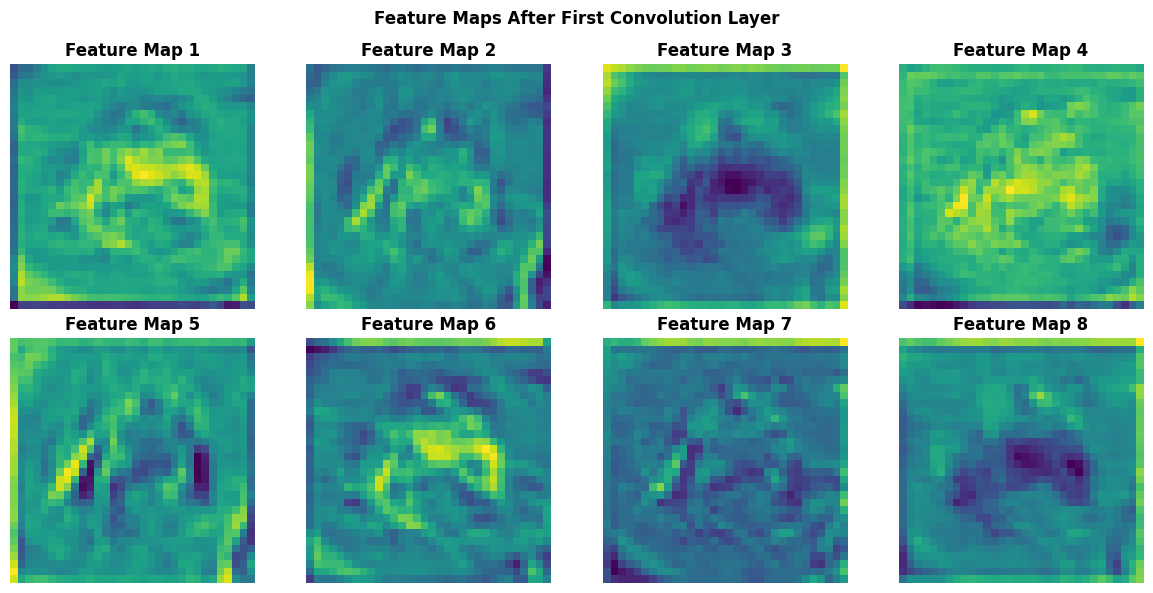

In [ ]:
# Task 4
conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
feature_maps = conv1(sample_img).detach()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, i].numpy(), cmap='viridis')
    ax.set_title(f"Feature Map {i+1}", fontweight='bold')
    ax.axis('off')
plt.suptitle("Feature Maps After First Convolution Layer", fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/7_feature_maps.png", dpi=200)
plt.show()

Input feature map size : 32
Max Pool output size   : 16
Avg Pool output size   : 16


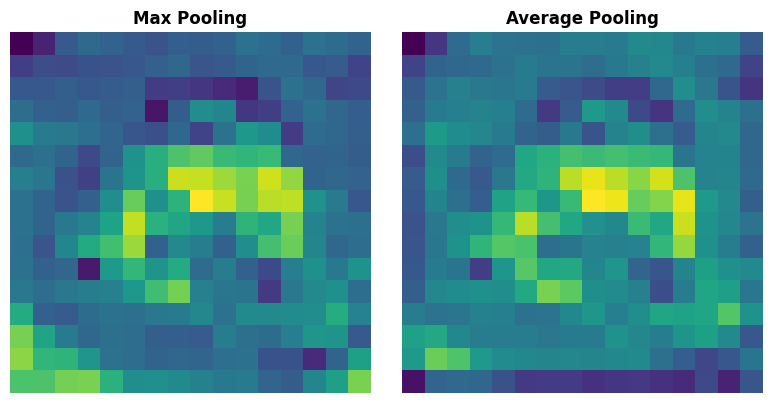

In [ ]:
# Task 5
maxpool = nn.MaxPool2d(2, 2)
avgpool = nn.AvgPool2d(2, 2)

max_out = maxpool(feature_maps)
avg_out = avgpool(feature_maps)

print("Input feature map size :", feature_maps.shape[-1])
print("Max Pool output size   :", max_out.shape[-1])
print("Avg Pool output size   :", avg_out.shape[-1])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(max_out[0, 0].numpy(), cmap='viridis')
axes[0].set_title("Max Pooling", fontweight='bold')
axes[0].axis('off')
axes[1].imshow(avg_out[0, 0].numpy(), cmap='viridis')
axes[1].set_title("Average Pooling", fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.savefig("outputs/pooling_comparison.png", dpi=200)
plt.show()

Max Pooling - Test Accuracy (5 epochs, 10k train subset): 0.5315
Average Pooling - Test Accuracy (5 epochs, 10k train subset): 0.5028


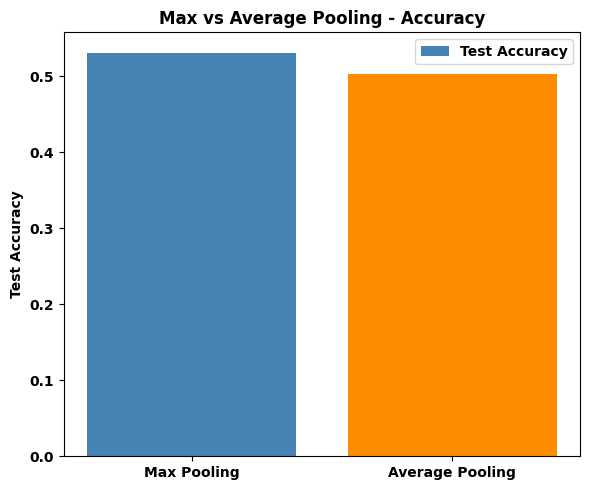

In [ ]:
# Task 5b - Accuracy comparison: train a small CNN with each pooling type
class PoolCNN(nn.Module):
    def __init__(self, pool_layer, num_classes=10):
        super(PoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool  = pool_layer
        self.fc1   = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x


quick_subset, _ = random_split(train_dataset, [10000, len(train_dataset) - 10000],
                                generator=torch.Generator().manual_seed(0))
quick_loader = DataLoader(quick_subset, batch_size=32, shuffle=True)
quick_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
quick_epochs = 5

def train_and_eval(pool_layer, name):
    torch.manual_seed(0)
    model = PoolCNN(pool_layer).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(quick_epochs):
        model.train()
        for images, labels in quick_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in quick_test_loader:
            images, labels = images.to(device), labels.to(device)
            _, predicted = torch.max(model(images), 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"{name} Pooling - Test Accuracy ({quick_epochs} epochs, 10k train subset): {acc:.4f}")
    return acc

max_acc = train_and_eval(nn.MaxPool2d(2, 2), "Max")
avg_acc = train_and_eval(nn.AvgPool2d(2, 2), "Average")

plt.figure(figsize=(6, 5))
plt.bar(["Max Pooling", "Average Pooling"], [max_acc, avg_acc],
        color=['steelblue', 'darkorange'], label='Test Accuracy')
plt.ylabel("Test Accuracy", fontweight='bold')
plt.title("Max vs Average Pooling - Accuracy", fontweight='bold')
plt.legend(prop={'weight': 'bold'})
plt.tight_layout()
plt.savefig("outputs/pooling_accuracy_comparison.png", dpi=200)
plt.show()
# Inference: Max pooling usually edges out average pooling on natural images
# because it keeps the strongest (most discriminative) activation in each
# window, while average pooling can dilute sharp edge/texture responses.


In [ ]:
# Task 6
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv2(x)))   # 16x16 -> 8x8
        x = x.view(x.size(0), -1)
        x = self.fc1(x)                        # Softmax applied inside CrossEntropyLoss
        return x

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size],
                                         generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_acc_list, val_acc_list = [], []
train_loss_list, val_loss_list = [], []

for epoch in range(num_epochs):
    model.train()
    correct, total, running_loss = 0, 0, 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    train_acc_list.append(train_acc); val_acc_list.append(val_acc)
    train_loss_list.append(train_loss); val_loss_list.append(val_loss)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")


Epoch [ 1/20]  Train Loss: 1.5419  Train Acc: 0.4530  Val Loss: 1.3511  Val Acc: 0.5154
Epoch [ 2/20]  Train Loss: 1.2110  Train Acc: 0.5775  Val Loss: 1.1615  Val Acc: 0.5944
Epoch [ 3/20]  Train Loss: 1.0861  Train Acc: 0.6248  Val Loss: 1.1026  Val Acc: 0.6150
Epoch [ 4/20]  Train Loss: 1.0043  Train Acc: 0.6497  Val Loss: 1.0452  Val Acc: 0.6386
Epoch [ 5/20]  Train Loss: 0.9457  Train Acc: 0.6734  Val Loss: 0.9993  Val Acc: 0.6558
Epoch [ 6/20]  Train Loss: 0.9037  Train Acc: 0.6876  Val Loss: 1.0006  Val Acc: 0.6528
Epoch [ 7/20]  Train Loss: 0.8691  Train Acc: 0.6999  Val Loss: 0.9938  Val Acc: 0.6634
Epoch [ 8/20]  Train Loss: 0.8404  Train Acc: 0.7098  Val Loss: 0.9566  Val Acc: 0.6656
Epoch [ 9/20]  Train Loss: 0.8111  Train Acc: 0.7222  Val Loss: 0.9369  Val Acc: 0.6826
Epoch [10/20]  Train Loss: 0.7895  Train Acc: 0.7276  Val Loss: 0.9458  Val Acc: 0.6798
Epoch [11/20]  Train Loss: 0.7681  Train Acc: 0.7352  Val Loss: 0.9419  Val Acc: 0.6792
Epoch [12/20]  Train Loss: 0.753

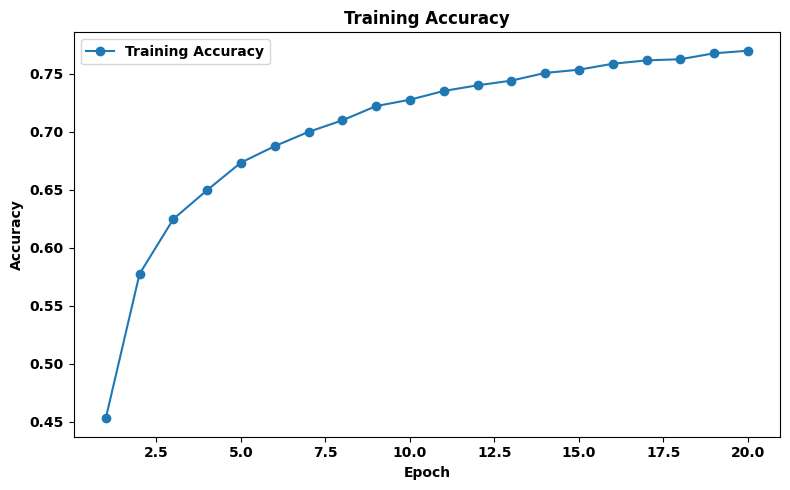

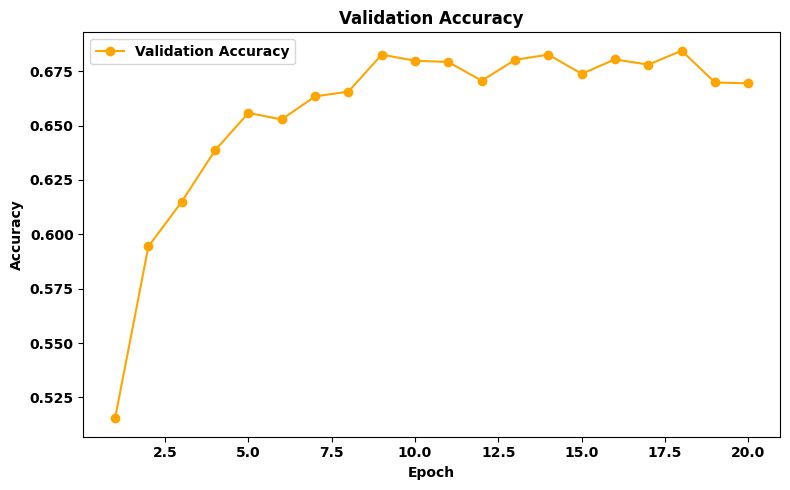

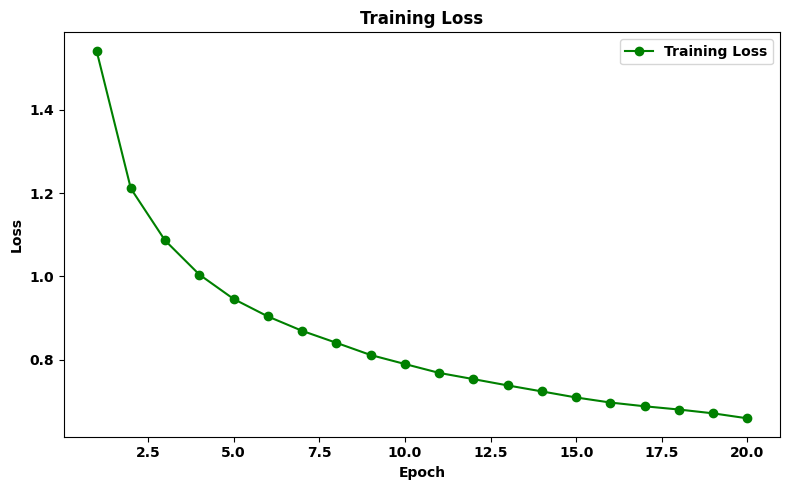

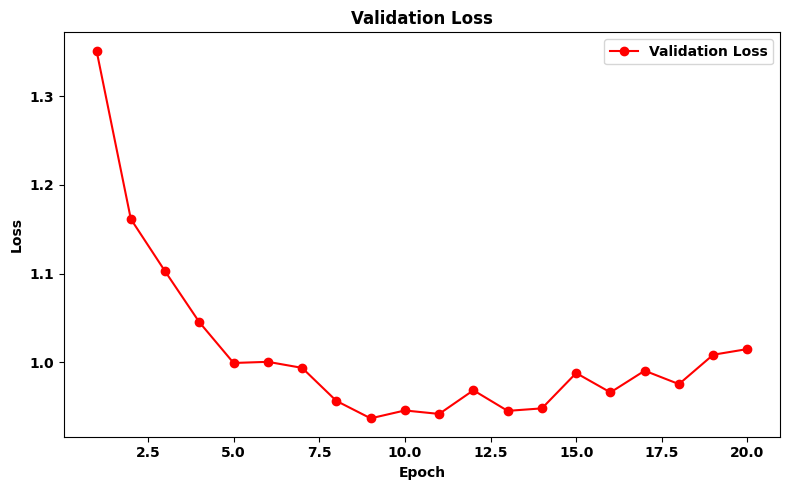

In [ ]:
# Training/Validation Accuracy & Loss plots
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_acc_list, label='Training Accuracy', marker='o')
plt.xlabel("Epoch", fontweight='bold'); plt.ylabel("Accuracy", fontweight='bold')
plt.title("Training Accuracy", fontweight='bold')
plt.legend(prop={'weight': 'bold'})
plt.tight_layout(); plt.savefig("outputs/3_training_accuracy.png", dpi=200); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, val_acc_list, label='Validation Accuracy', marker='o', color='orange')
plt.xlabel("Epoch", fontweight='bold'); plt.ylabel("Accuracy", fontweight='bold')
plt.title("Validation Accuracy", fontweight='bold')
plt.legend(prop={'weight': 'bold'})
plt.tight_layout(); plt.savefig("outputs/4_validation_accuracy.png", dpi=200); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss_list, label='Training Loss', marker='o', color='green')
plt.xlabel("Epoch", fontweight='bold'); plt.ylabel("Loss", fontweight='bold')
plt.title("Training Loss", fontweight='bold')
plt.legend(prop={'weight': 'bold'})
plt.tight_layout(); plt.savefig("outputs/5_training_loss.png", dpi=200); plt.show()


plt.figure(figsize=(8, 5))
plt.plot(epochs_range, val_loss_list, label='Validation Loss', marker='o', color='red')
plt.xlabel("Epoch", fontweight='bold'); plt.ylabel("Loss", fontweight='bold')
plt.title("Validation Loss", fontweight='bold')
plt.legend(prop={'weight': 'bold'})
plt.tight_layout(); plt.savefig("outputs/6_validation_loss.png", dpi=200); plt.show()


Test Accuracy      : 0.6790
Precision (macro)  : 0.6872
Recall (macro)     : 0.6790
F1-score (macro)   : 0.6768
Trainable parameters: 25578

Classification Report:
               precision    recall  f1-score   support

    airplane       0.65      0.80      0.71      1000
  automobile       0.75      0.86      0.80      1000
        bird       0.54      0.58      0.56      1000
         cat       0.52      0.48      0.50      1000
        deer       0.60      0.66      0.63      1000
         dog       0.71      0.47      0.57      1000
        frog       0.66      0.83      0.73      1000
       horse       0.76      0.72      0.74      1000
        ship       0.87      0.70      0.78      1000
       truck       0.82      0.69      0.75      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



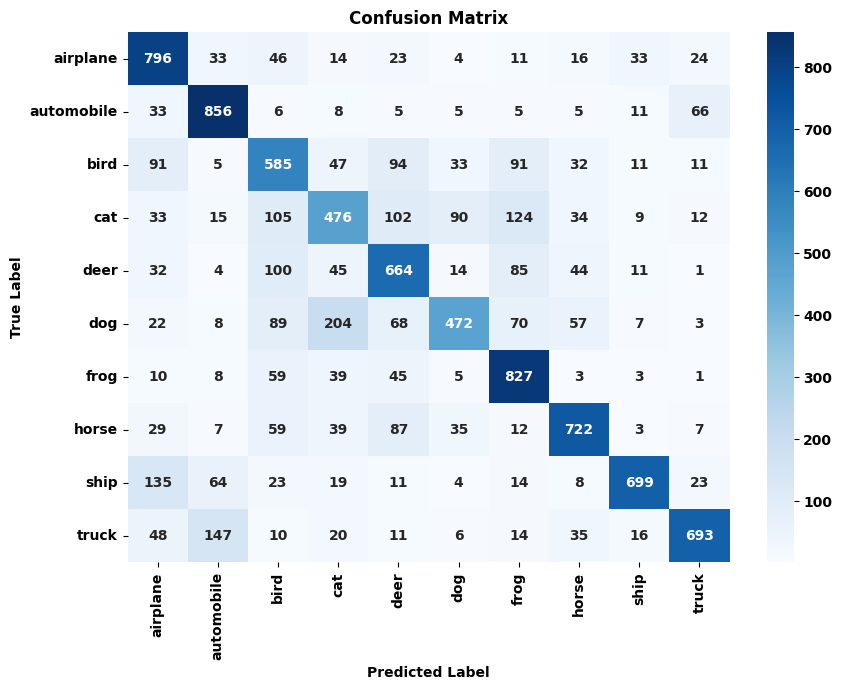

In [ ]:

model.eval()
all_preds, all_labels = [], []
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = correct / total
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Test Accuracy      : {test_acc:.4f}")
print(f"Precision (macro)  : {precision:.4f}")
print(f"Recall (macro)     : {recall:.4f}")
print(f"F1-score (macro)   : {f1:.4f}")
print(f"Trainable parameters: {num_params}")
print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=classes))


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes,
            annot_kws={"weight": "bold"})
plt.xlabel("Predicted Label", fontweight='bold')
plt.ylabel("True Label", fontweight='bold')
plt.title("Confusion Matrix", fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/8_confusion_matrix.png", dpi=200)
plt.show()


Exercise 1 - Output size: 32
Exercise 2 - Trainable parameters: 1792


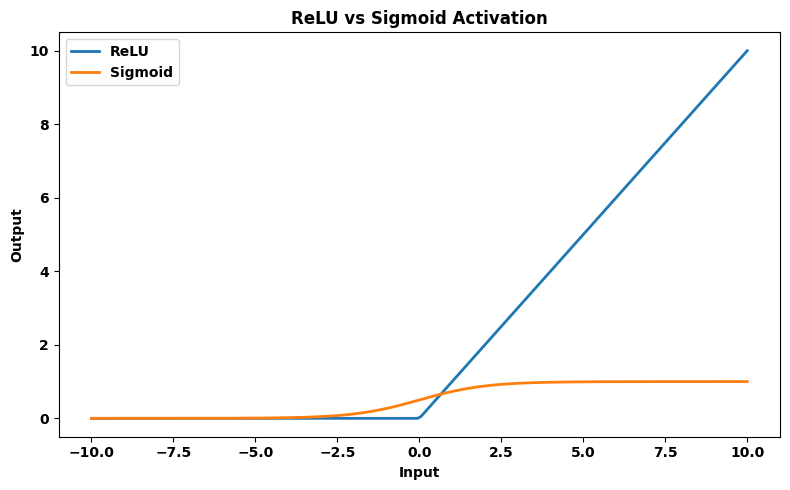

In [ ]:
# Additional Exercises
# 1. Output size for a 64x64 image, 5x5 kernel, stride 2, padding 2
N, Fk, P, S = 64, 5, 2, 2
out_size = (N - Fk + 2 * P) // S + 1
print("Exercise 1 - Output size:", out_size)

# 2. Trainable parameters: 64 filters of 3x3 kernel, RGB (3-channel) input
params = (3 * 3 * 3 + 1) * 64
print("Exercise 2 - Trainable parameters:", params)

# 3. ReLU vs Sigmoid activation comparison
x = torch.linspace(-10, 10, 200)
relu_vals = F.relu(x)
sigmoid_vals = torch.sigmoid(x)

plt.figure(figsize=(8, 5))
plt.plot(x.numpy(), relu_vals.numpy(), label='ReLU', linewidth=2)
plt.plot(x.numpy(), sigmoid_vals.numpy(), label='Sigmoid', linewidth=2)
plt.xlabel("Input", fontweight='bold'); plt.ylabel("Output", fontweight='bold')
plt.title("ReLU vs Sigmoid Activation", fontweight='bold')
plt.legend(prop={'weight': 'bold'})
plt.tight_layout(); plt.savefig("outputs/relu_vs_sigmoid.png", dpi=200); plt.show()
